<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/12_timeseries_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 12 — Time Series Augmentation

## What This Notebook Covers
Time series augmentation is fundamentally different from image or text augmentation.
A time series is an ordered sequence of values where:
- **Temporal order matters** — you cannot shuffle randomly like image patches
- **Local patterns matter** — peaks, troughs, and slopes carry information
- **Scale can vary** — the same pattern at different amplitudes is still the same pattern

Good time series augmentation preserves the underlying temporal pattern
while adding realistic variation in amplitude, timing, and noise.

**Techniques covered:**
- Jitter (additive Gaussian noise)
- Scaling (amplitude multiplication)
- Time warping (non-linear time axis distortion)
- Window slicing (crop a random sub-window)
- Window warping (speed up or slow down a segment)
- Magnitude warping (smooth amplitude variation)
- Permutation (shuffle segments)
- Drift (add a random walk component)
- Frequency domain augmentation (Fourier-based)
- tsaug library pipeline
- A/B test: baseline classifier vs augmented training

**Dataset:** UCR time series archive (ECG / HAR subset) + synthetic data


In [1]:
!pip install tsaug --quiet

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.interpolate import CubicSpline
import tsaug
import random

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('tsaug  :', tsaug.__version__)
print('Device :', device)

tsaug  : 0.2.1
Device : cuda


## 1. Generate Synthetic Time Series Dataset

We generate 4 classes of time series with distinct temporal patterns:
- **Sine**: smooth periodic oscillation
- **Square**: abrupt transitions between high and low
- **Sawtooth**: linear ramp with sharp drop
- **ECG-like**: spike train with realistic cardiac waveform shape

Each class has 300 samples with random noise and phase shifts.


Train: (960, 128), Test: (240, 128)
Sequence length: 128


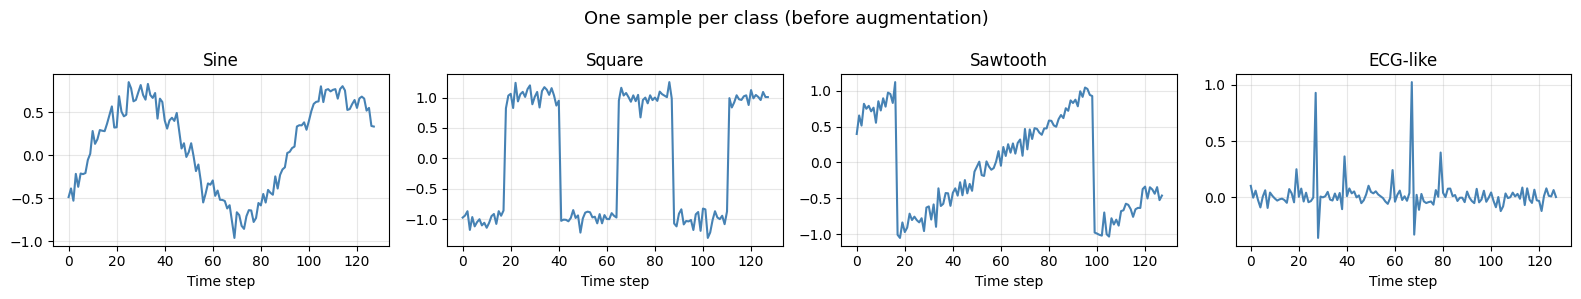

In [2]:
SEQ_LEN = 128
N_PER_CLASS = 300
CLASS_NAMES = ['Sine', 'Square', 'Sawtooth', 'ECG-like']


def make_sine(n, seq_len, noise_std=0.1):
    t = np.linspace(0, 2 * np.pi, seq_len)
    samples = []
    for _ in range(n):
        freq  = np.random.uniform(1.0, 3.0)
        phase = np.random.uniform(0, 2 * np.pi)
        amp   = np.random.uniform(0.7, 1.3)
        s     = amp * np.sin(freq * t + phase)
        s    += np.random.randn(seq_len) * noise_std
        samples.append(s)
    return np.array(samples)


def make_square(n, seq_len, noise_std=0.1):
    t = np.linspace(0, 2 * np.pi, seq_len)
    samples = []
    for _ in range(n):
        freq  = np.random.uniform(1.0, 3.0)
        phase = np.random.uniform(0, 2 * np.pi)
        s     = np.sign(np.sin(freq * t + phase)).astype(float)
        s    += np.random.randn(seq_len) * noise_std
        samples.append(s)
    return np.array(samples)


def make_sawtooth(n, seq_len, noise_std=0.1):
    t = np.linspace(0, 1, seq_len)
    samples = []
    for _ in range(n):
        freq  = np.random.uniform(1.0, 4.0)
        phase = np.random.uniform(0, 1)
        s     = 2 * ((t * freq + phase) % 1) - 1
        s    += np.random.randn(seq_len) * noise_std
        samples.append(s)
    return np.array(samples)


def make_ecg_like(n, seq_len, noise_std=0.05):
    samples = []
    for _ in range(n):
        s = np.zeros(seq_len)
        beat_len = np.random.randint(30, 50)
        offset   = np.random.randint(0, beat_len)
        for start in range(offset, seq_len - beat_len, beat_len):
            beat = np.zeros(beat_len)
            p    = int(beat_len * 0.2)
            r    = int(beat_len * 0.4)
            t_w  = int(beat_len * 0.7)
            if p < beat_len: beat[p] = 0.25
            if r < beat_len: beat[r] = 1.0
            if r+1 < beat_len: beat[r+1] = -0.3
            if t_w < beat_len: beat[t_w] = 0.35
            s[start:start+beat_len] = beat
        s += np.random.randn(seq_len) * noise_std
        samples.append(s)
    return np.array(samples)


X_all = np.concatenate([
    make_sine(N_PER_CLASS, SEQ_LEN),
    make_square(N_PER_CLASS, SEQ_LEN),
    make_sawtooth(N_PER_CLASS, SEQ_LEN),
    make_ecg_like(N_PER_CLASS, SEQ_LEN),
], axis=0).astype(np.float32)

y_all = np.array([i for i in range(4) for _ in range(N_PER_CLASS)])

# Shuffle
idx   = np.random.permutation(len(X_all))
X_all = X_all[idx]
y_all = y_all[idx]

split     = int(0.8 * len(X_all))
X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Sequence length: {SEQ_LEN}')

# Preview one sample per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for cls, ax in enumerate(axes):
    mask = (y_train == cls)
    ax.plot(X_train[mask][0], color='steelblue', linewidth=1.5)
    ax.set_title(CLASS_NAMES[cls], fontsize=12)
    ax.set_xlabel('Time step')
    ax.grid(True, alpha=0.3)
plt.suptitle('One sample per class (before augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Visualisation Helper


In [3]:
def show_ts_aug(original, augmented, title='', color_aug='tomato'):
    """
    Overlay original (blue) and augmented (red) time series on the same axes.
    Shows multiple augmented versions side by side.
    original  : 1D numpy array
    augmented : list of 1D numpy arrays (up to 4)
    """
    n_aug = min(len(augmented), 4)
    fig, axes = plt.subplots(1, n_aug, figsize=(4 * n_aug, 3), sharey=True)
    if n_aug == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(original, color='steelblue', linewidth=1.5,
                label='Original', alpha=0.8)
        ax.plot(augmented[i], color=color_aug, linewidth=1.5,
                label='Augmented', alpha=0.8)
        ax.set_xlabel('Time step')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Reference sample we'll use throughout
SAMPLE = X_train[y_train == 0][0].copy()   # one sine wave
print('Reference sample ready.')

Reference sample ready.


## 3. Jitter — Additive Gaussian Noise

The simplest augmentation: add zero-mean Gaussian noise to every time step.
Simulates sensor noise and measurement error.
Must keep sigma small relative to signal amplitude — 5-10% of std is typical.


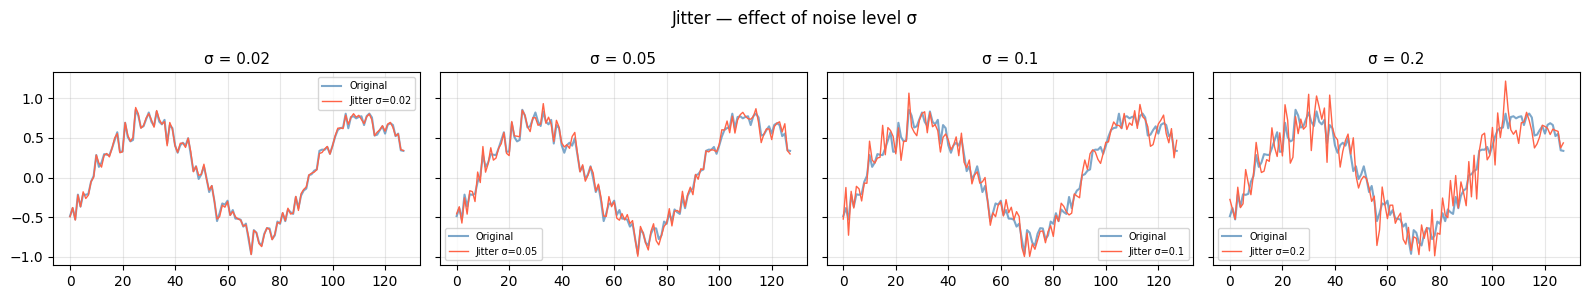

In [4]:
def jitter(x, sigma=0.05):
    """
    Add zero-mean Gaussian noise to every time step.
    sigma controls noise amplitude — typically 0.03 to 0.1.
    """
    return x + np.random.randn(*x.shape) * sigma


# Show effect of different sigma values
sigmas = [0.02, 0.05, 0.1, 0.2]
aug_versions = [jitter(SAMPLE, sigma=s) for s in sigmas]

fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for ax, aug, s in zip(axes, aug_versions, sigmas):
    ax.plot(SAMPLE, color='steelblue', linewidth=1.5, label='Original', alpha=0.7)
    ax.plot(aug, color='tomato', linewidth=1.0, label=f'Jitter σ={s}')
    ax.set_title(f'σ = {s}', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
plt.suptitle('Jitter — effect of noise level σ', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Scaling — Amplitude Multiplication

Multiply all values by a random scalar. Teaches the model that the same
pattern at different amplitudes belongs to the same class.
Critical for sensor data where calibration can vary.


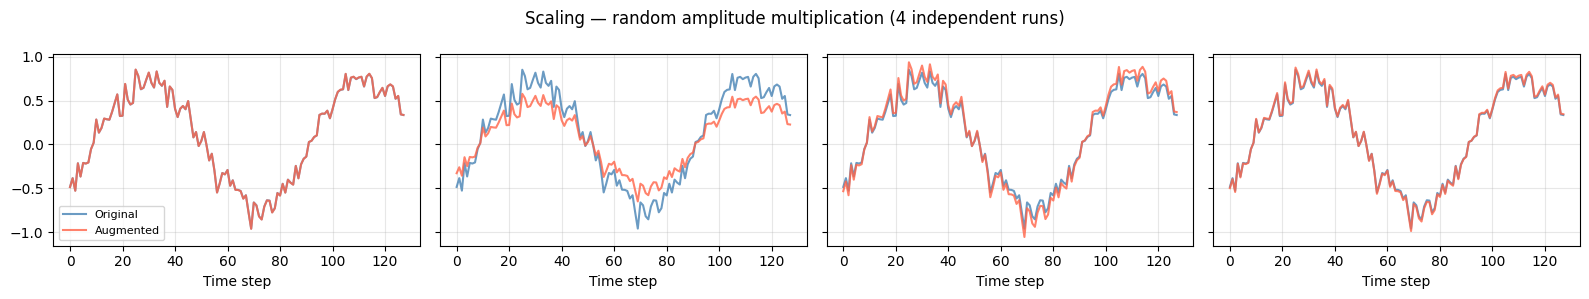

In [5]:
def scaling(x, sigma=0.2):
    """
    Multiply entire series by a random scalar drawn from N(1.0, sigma).
    sigma=0.2 means scale factor varies between roughly 0.6 and 1.4.
    """
    scale_factor = np.random.normal(1.0, sigma)
    return x * scale_factor


aug_versions = [scaling(SAMPLE, sigma=0.3) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Scaling — random amplitude multiplication (4 independent runs)')

## 5. Time Warping — Non-linear Time Axis Distortion

Time warping stretches and compresses different parts of the time axis
using a smooth random warp function. Some segments speed up, others slow down.
This simulates natural variation in the speed of underlying processes:
heartbeat rate variation, gait speed changes, speech rate variation.

Implementation: generate random knots, fit a cubic spline, resample.


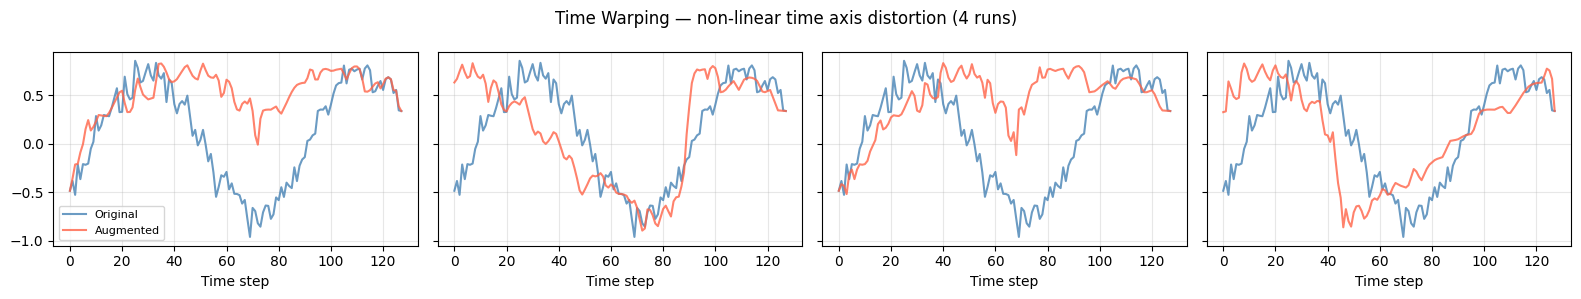

In [6]:
def time_warp(x, sigma=0.2, n_knots=4):
    """
    Apply smooth non-linear time warping to a 1D time series.

    Steps:
    1. Place n_knots random control points along the time axis
    2. Fit a cubic spline through the control points
    3. Use the spline as the new time axis (cumulative warp)
    4. Resample the original series at the new time positions
    """
    T = len(x)
    # Place control points
    knot_xs = np.linspace(0, T - 1, n_knots + 2)
    # Add random offsets to intermediate knots (keep endpoints fixed)
    knot_ys = np.copy(knot_xs)
    knot_ys[1:-1] += np.random.randn(n_knots) * sigma * T

    # Fit cubic spline through control points
    cs = CubicSpline(knot_xs, knot_ys)

    # New warped time axis
    orig_t  = np.arange(T)
    warp_t  = cs(orig_t)
    warp_t  = np.clip(warp_t, 0, T - 1)

    # Resample original series at warped positions
    new_t   = np.linspace(0, T - 1, T)
    warped  = np.interp(new_t, warp_t, x)
    return warped.astype(x.dtype)


aug_versions = [time_warp(SAMPLE, sigma=0.15) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Time Warping — non-linear time axis distortion (4 runs)')

## 6. Window Slicing — Random Sub-window Crop

Crop a random contiguous window from the series and resize back to
the original length. The model sees a zoomed-in portion of the pattern.
Equivalent to RandomCrop for images.


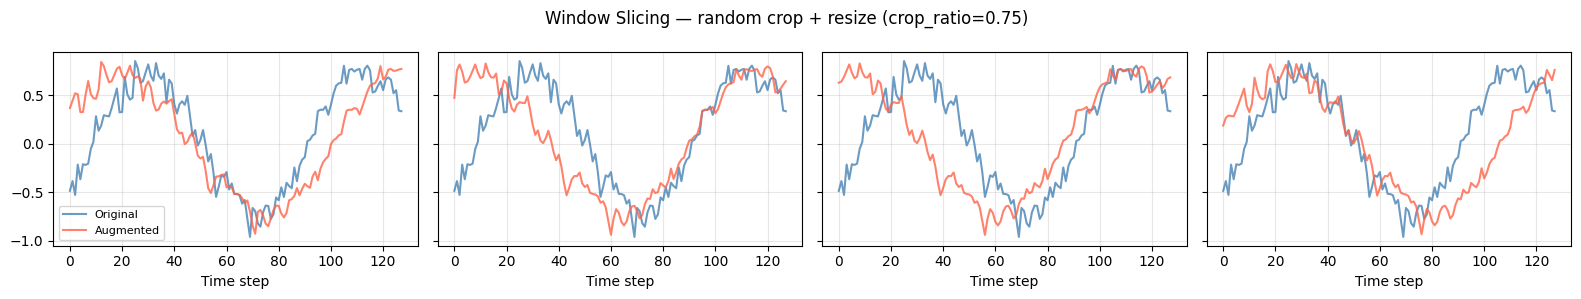

In [7]:
def window_slice(x, crop_ratio=0.8):
    """
    Crop a random window of length crop_ratio * T and resize back to T.
    crop_ratio=0.8 means we keep 80% of the signal and stretch it to fill.
    """
    T        = len(x)
    win_len  = int(T * crop_ratio)
    start    = np.random.randint(0, T - win_len)
    window   = x[start : start + win_len]
    # Resample back to original length
    resampled = np.interp(
        np.linspace(0, win_len - 1, T),
        np.arange(win_len),
        window
    )
    return resampled.astype(x.dtype)


aug_versions = [window_slice(SAMPLE, crop_ratio=0.75) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Window Slicing — random crop + resize (crop_ratio=0.75)')

## 7. Window Warping — Speed Up/Slow Down a Segment

Select a random window and either compress it (speed up) or
expand it (slow down), then pad/trim back to original length.
More targeted than full time warping — only one segment is affected.


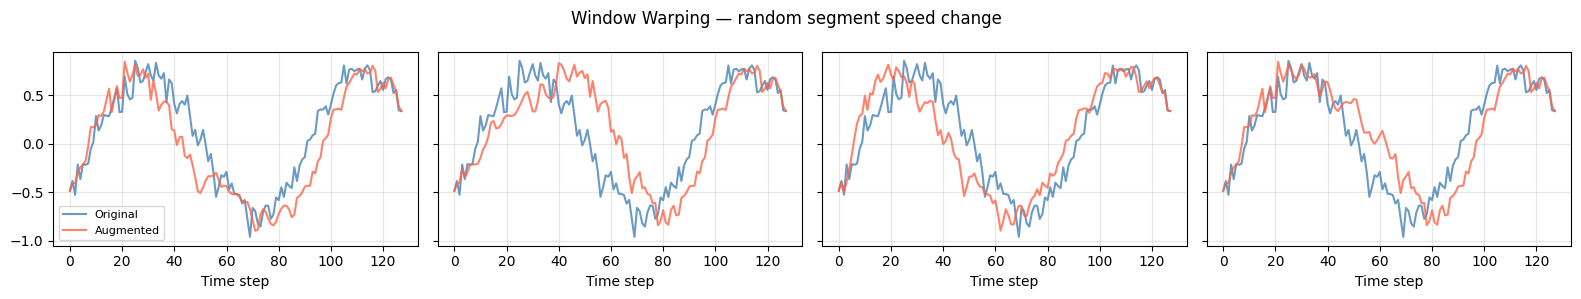

In [8]:
def window_warp(x, window_ratio=0.2, scales=(0.5, 2.0)):
    """
    Pick a random window of window_ratio fraction of the series.
    Randomly speed up or slow down that window by a scale factor.
    Remaining series is adjusted to maintain total length.
    """
    T        = len(x)
    win_len  = max(int(T * window_ratio), 2)
    start    = np.random.randint(0, T - win_len)

    scale    = np.random.choice(scales)   # either compress or expand
    window   = x[start : start + win_len]

    # Resample window
    new_win_len = max(int(win_len * scale), 1)
    warped_win  = np.interp(
        np.linspace(0, win_len - 1, new_win_len),
        np.arange(win_len),
        window
    )

    # Reconstruct full series
    result = np.concatenate([
        x[:start],
        warped_win,
        x[start + win_len:]
    ])

    # Resize back to original length
    result = np.interp(
        np.linspace(0, len(result) - 1, T),
        np.arange(len(result)),
        result
    )
    return result.astype(x.dtype)


aug_versions = [window_warp(SAMPLE) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Window Warping — random segment speed change')

## 8. Magnitude Warping — Smooth Amplitude Variation

Multiply the series element-wise by a smooth random curve.
Unlike scaling (constant multiplier), magnitude warping applies
a different scale factor at each time step — the amplitude envelope
itself becomes non-uniform.


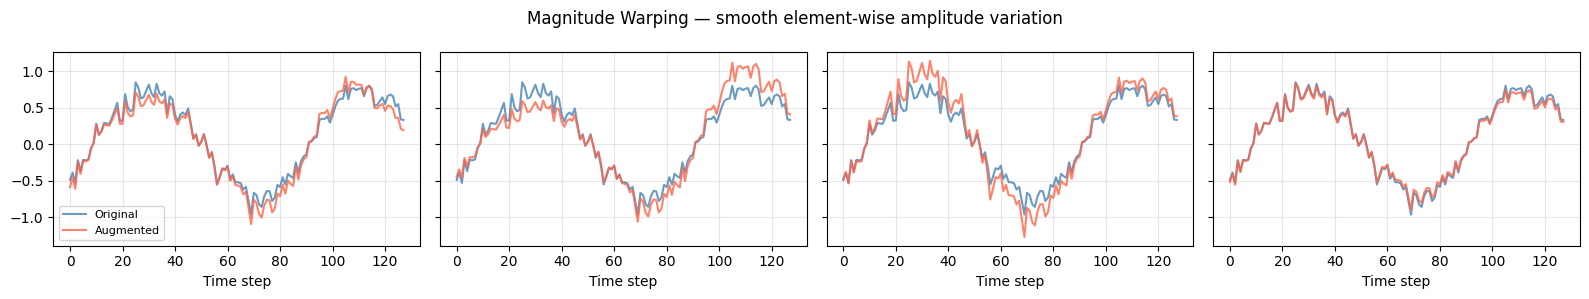

In [9]:
def magnitude_warp(x, sigma=0.2, n_knots=4):
    """
    Multiply series by a smooth random curve (element-wise scale).
    The curve is generated by fitting a cubic spline through
    random control points centered around 1.0.
    """
    T      = len(x)
    knot_x = np.linspace(0, T - 1, n_knots)
    knot_y = np.random.normal(1.0, sigma, n_knots)   # random multipliers ~1.0

    cs     = CubicSpline(knot_x, knot_y)
    warp   = cs(np.arange(T))
    return (x * warp).astype(x.dtype)


aug_versions = [magnitude_warp(SAMPLE, sigma=0.25) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Magnitude Warping — smooth element-wise amplitude variation')

## 9. Drift — Adding a Random Walk Component

Add a slow random drift to the series — simulates sensor baseline drift,
temperature effects on measurements, or gradual concept drift in data.


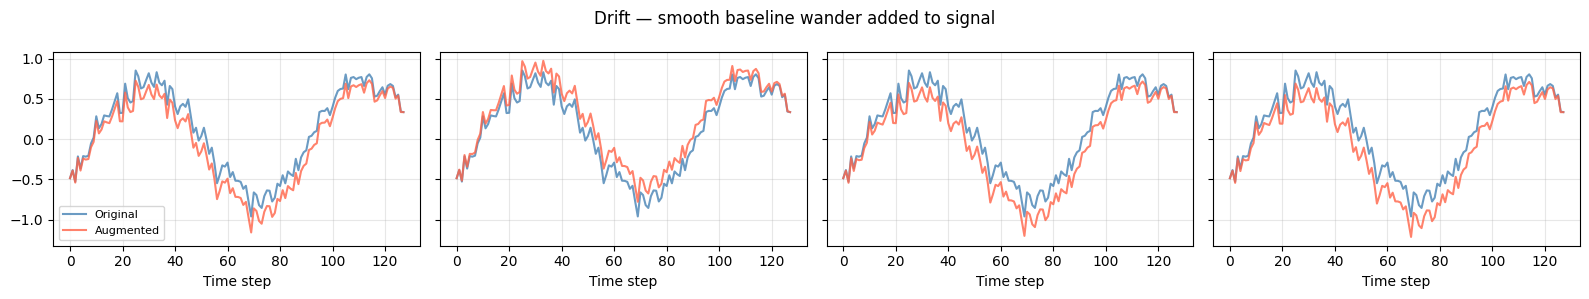

In [10]:
def add_drift(x, max_drift=0.3):
    """
    Add a smooth random drift (low-frequency trend) to the series.
    Drift is a cubic spline with 3 random control points.
    """
    T = len(x)
    n_knots = 3
    knot_x  = np.linspace(0, T - 1, n_knots)
    knot_y  = np.random.uniform(-max_drift, max_drift, n_knots)
    knot_y[0] = knot_y[-1] = 0   # start and end at zero drift

    cs    = CubicSpline(knot_x, knot_y)
    drift = cs(np.arange(T))
    return (x + drift).astype(x.dtype)


aug_versions = [add_drift(SAMPLE, max_drift=0.4) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Drift — smooth baseline wander added to signal')

## 10. Permutation — Shuffle Temporal Segments

Split the series into N equal segments and shuffle their order.
Useful for training models that should learn local patterns
rather than global temporal order.
Similar to segment shuffling in video augmentation.


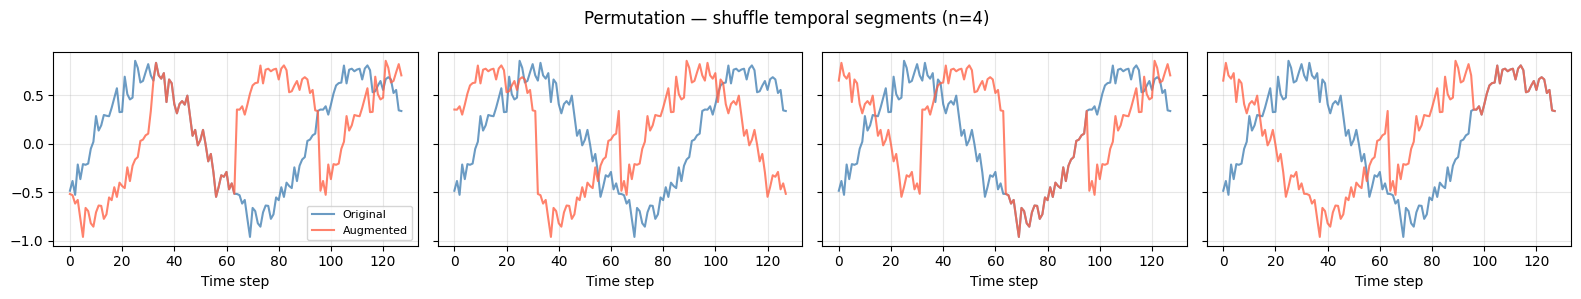

In [11]:
def permutation(x, n_segments=4):
    """
    Split series into n_segments equal pieces and randomly shuffle them.
    Output has same length but scrambled segment order.
    """
    T       = len(x)
    seg_len = T // n_segments
    segs    = [x[i*seg_len:(i+1)*seg_len] for i in range(n_segments)]
    remainder = x[n_segments*seg_len:]   # handle non-divisible lengths
    random.shuffle(segs)
    return np.concatenate(segs + [remainder]).astype(x.dtype)


aug_versions = [permutation(SAMPLE, n_segments=4) for _ in range(4)]
show_ts_aug(SAMPLE, aug_versions,
            title='Permutation — shuffle temporal segments (n=4)')

## 11. Frequency Domain Augmentation

Transform to the frequency domain (FFT), perturb the spectrum,
then transform back (IFFT). This can:
- Add noise to frequency components (frequency jitter)
- Remove high-frequency components (low-pass filtering)
- Shift the dominant frequency (pitch shift for audio-like signals)


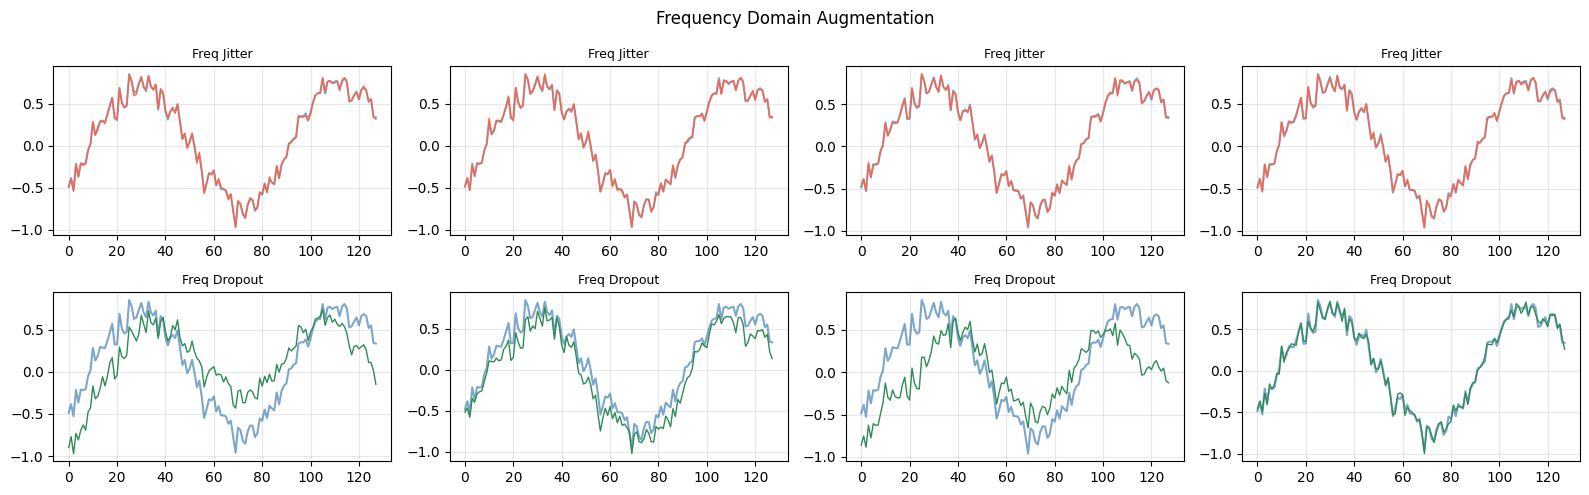

In [12]:
def freq_domain_jitter(x, noise_std=0.05):
    """
    Add Gaussian noise to each Fourier coefficient magnitude.
    Perturbs the frequency content while preserving rough shape.
    """
    X_fft   = np.fft.rfft(x)
    # Add complex noise to each coefficient
    noise   = (np.random.randn(len(X_fft)) + 1j * np.random.randn(len(X_fft))) * noise_std
    X_fft  += noise
    return np.fft.irfft(X_fft, n=len(x)).astype(x.dtype)


def freq_dropout(x, drop_ratio=0.1):
    """
    Randomly zero out drop_ratio fraction of Fourier coefficients.
    Removes specific frequency components to create spectral variation.
    """
    X_fft  = np.fft.rfft(x).copy()
    n_drop = int(len(X_fft) * drop_ratio)
    drop_idx = np.random.choice(len(X_fft), n_drop, replace=False)
    X_fft[drop_idx] = 0
    return np.fft.irfft(X_fft, n=len(x)).astype(x.dtype)


fig, axes = plt.subplots(2, 4, figsize=(16, 5))
aug_jitter  = [freq_domain_jitter(SAMPLE, noise_std=0.1) for _ in range(4)]
aug_dropout = [freq_dropout(SAMPLE, drop_ratio=0.15) for _ in range(4)]

for i in range(4):
    axes[0, i].plot(SAMPLE, color='steelblue', alpha=0.7, linewidth=1.5)
    axes[0, i].plot(aug_jitter[i], color='tomato', linewidth=1.0)
    axes[0, i].set_title('Freq Jitter', fontsize=9)
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].plot(SAMPLE, color='steelblue', alpha=0.7, linewidth=1.5)
    axes[1, i].plot(aug_dropout[i], color='seagreen', linewidth=1.0)
    axes[1, i].set_title('Freq Dropout', fontsize=9)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Frequency Domain Augmentation', fontsize=12)
plt.tight_layout()
plt.show()

## 12. tsaug Library Pipeline

`tsaug` provides a clean pipeline API similar to albumentations.
Operators are chained with `@` and have probability control.


tsaug pipeline preview (5 independent runs):


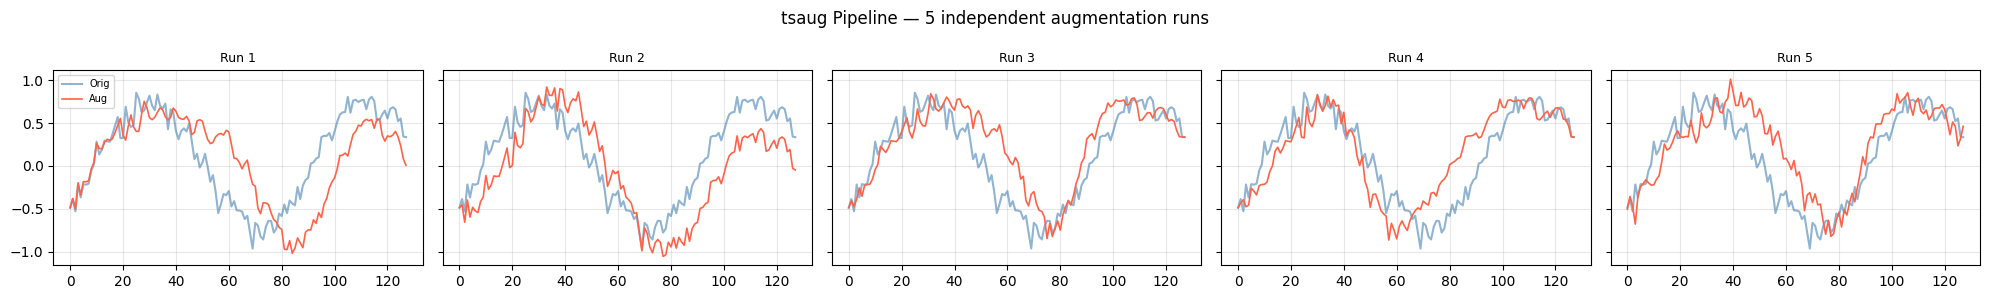

In [13]:
from tsaug import TimeWarp, Crop, Quantize, Drift, Reverse, AddNoise

# Build tsaug pipeline
# @ chains augmenters; * N repeats; each has a probability
ts_pipeline = (
    AddNoise(scale=0.05) @ 0.5     # add noise 50% of the time
    + TimeWarp(n_speed_change=3, max_speed_ratio=2) @ 0.5
    + Drift(max_drift=(0.0, 0.3), n_drift_points=5) @ 0.4
    + Crop(size=int(SEQ_LEN * 0.8)) @ 0.3
    + Reverse() @ 0.1
)

# tsaug expects shape (n_samples, seq_len) or (n_samples, seq_len, n_channels)
sample_batch = SAMPLE.reshape(1, -1)   # (1, 128)

print('tsaug pipeline preview (5 independent runs):')
fig, axes = plt.subplots(1, 5, figsize=(20, 3), sharey=True)
for i, ax in enumerate(axes):
    aug_result = ts_pipeline.augment(sample_batch)  # (1, 128) or variable
    aug_series = aug_result[0]
    # Resample to SEQ_LEN if Crop changed the length
    if len(aug_series) != SEQ_LEN:
        aug_series = np.interp(
            np.linspace(0, len(aug_series)-1, SEQ_LEN),
            np.arange(len(aug_series)), aug_series
        )
    ax.plot(SAMPLE, color='steelblue', alpha=0.6, linewidth=1.5, label='Orig')
    ax.plot(aug_series, color='tomato', linewidth=1.2, label='Aug')
    ax.set_title(f'Run {i+1}', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('tsaug Pipeline — 5 independent augmentation runs', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Full Augmentation Pipeline for Training


Full augmentation pipeline defined.


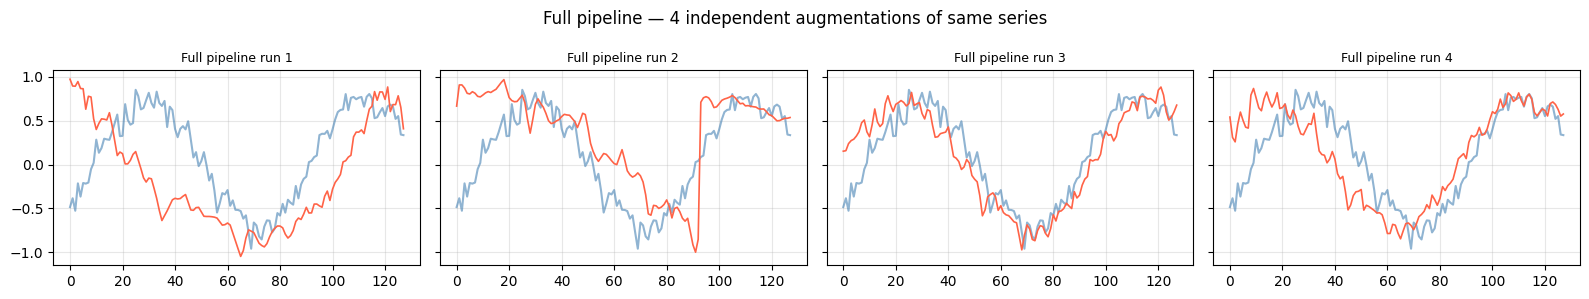

In [14]:
def augment_ts(x, seq_len=SEQ_LEN):
    """
    Full time series augmentation pipeline.
    Each technique applied independently with its own probability.
    Output always has length seq_len.
    """
    x = x.copy()

    if random.random() < 0.6:
        x = jitter(x, sigma=np.random.uniform(0.02, 0.08))

    if random.random() < 0.5:
        x = scaling(x, sigma=np.random.uniform(0.1, 0.25))

    if random.random() < 0.5:
        x = magnitude_warp(x, sigma=0.2)

    if random.random() < 0.4:
        x = time_warp(x, sigma=0.15)

    if random.random() < 0.3:
        x = window_slice(x, crop_ratio=np.random.uniform(0.75, 0.95))

    if random.random() < 0.3:
        x = add_drift(x, max_drift=0.2)

    if random.random() < 0.2:
        x = freq_domain_jitter(x, noise_std=0.05)

    # Ensure correct length
    if len(x) != seq_len:
        x = np.interp(np.linspace(0, len(x)-1, seq_len), np.arange(len(x)), x)

    return x.astype(np.float32)


print('Full augmentation pipeline defined.')

# Preview
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    random.seed(i * 7)
    aug = augment_ts(SAMPLE)
    ax.plot(SAMPLE, color='steelblue', alpha=0.6, linewidth=1.5)
    ax.plot(aug, color='tomato', linewidth=1.2)
    ax.set_title(f'Full pipeline run {i+1}', fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Full pipeline — 4 independent augmentations of same series', fontsize=12)
plt.tight_layout()
plt.show()

## 14. PyTorch Dataset & 1D CNN Classifier


In [15]:
class TSDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        if self.augment:
            x = augment_ts(x)
        # Shape: (1, seq_len) — 1D CNN expects (batch, channels, length)
        return torch.tensor(x).unsqueeze(0), torch.tensor(int(self.y[idx]))


BATCH_SIZE = 32

train_ds_base = TSDataset(X_train, y_train, augment=False)
train_ds_aug  = TSDataset(X_train, y_train, augment=True)
test_ds       = TSDataset(X_test,  y_test,  augment=False)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE, shuffle=True)
test_loader       = DataLoader(test_ds,        batch_size=BATCH_SIZE, shuffle=False)

X_b, y_b = next(iter(train_loader_aug))
print(f'Batch shape: {X_b.shape}  (B, 1, seq_len)')


class TSClassifier1D(nn.Module):
    """
    1D CNN for time series classification.
    Uses temporal convolutions to extract local patterns,
    then global average pooling to aggregate over time.
    """
    def __init__(self, seq_len=SEQ_LEN, n_classes=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=8, padding=4), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


m = TSClassifier1D().to(device)
print(f'Output shape: {m(X_b.to(device)).shape}  (expect [32, 4])')
print(f'Parameters  : {sum(p.numel() for p in m.parameters()):,}')

Batch shape: torch.Size([32, 1, 128])  (B, 1, seq_len)
Output shape: torch.Size([32, 4])  (expect [32, 4])
Parameters  : 44,260


## 15. A/B Test: No Augmentation vs Full Pipeline


In [16]:
def train_ts_model(train_loader, label='', epochs=30):
    torch.manual_seed(42)
    model     = TSClassifier1D(n_classes=4).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc  = 0.0
    hist      = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
        train_acc = correct / total

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)

        if (epoch + 1) % 10 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | '
                  f'train={train_acc:.4f} | test={test_acc:.4f}')

    print(f'[{label}] Best test accuracy: {best_acc:.4f}\n')
    return hist, best_acc


print('Training WITHOUT augmentation...')
hist_base, acc_base = train_ts_model(train_loader_base, 'No aug', epochs=30)

print('Training WITH augmentation pipeline...')
hist_aug, acc_aug = train_ts_model(train_loader_aug, 'Augmented', epochs=30)

Training WITHOUT augmentation...
[No aug] Epoch 10 | train=1.0000 | test=1.0000
[No aug] Epoch 20 | train=1.0000 | test=1.0000
[No aug] Epoch 30 | train=1.0000 | test=1.0000
[No aug] Best test accuracy: 1.0000

Training WITH augmentation pipeline...
[Augmented] Epoch 10 | train=0.9760 | test=1.0000
[Augmented] Epoch 20 | train=0.9844 | test=1.0000
[Augmented] Epoch 30 | train=0.9802 | test=1.0000
[Augmented] Best test accuracy: 1.0000



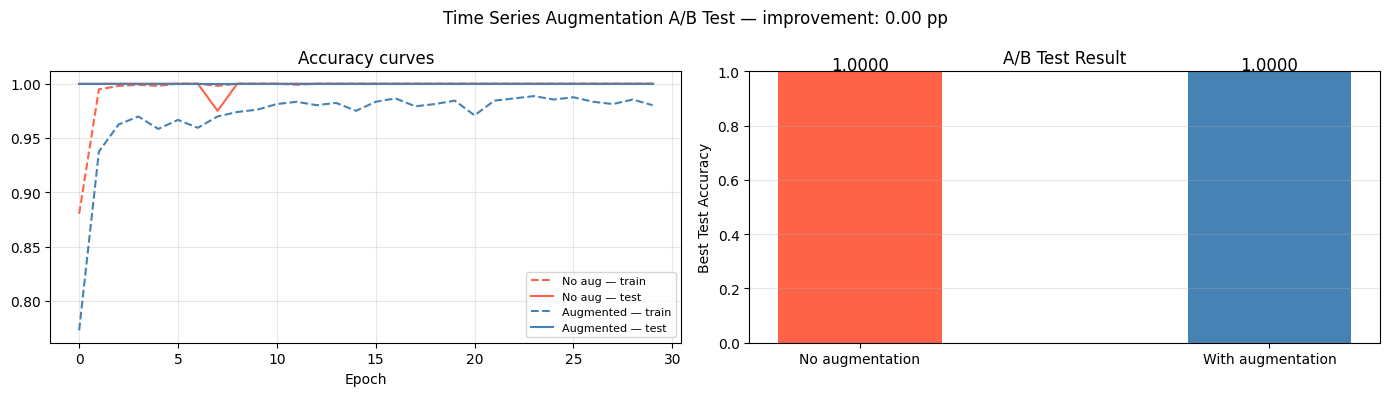

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_acc'], '--', color='tomato',    label='No aug — train')
axes[0].plot(hist_base['test_acc'],        color='tomato',    label='No aug — test')
axes[0].plot(hist_aug['train_acc'],  '--', color='steelblue', label='Augmented — train')
axes[0].plot(hist_aug['test_acc'],         color='steelblue', label='Augmented — test')
axes[0].set_title('Accuracy curves')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(
    ['No augmentation', 'With augmentation'],
    [acc_base, acc_aug],
    color=['tomato', 'steelblue'], width=0.4
)
for bar, acc in zip(bars, [acc_base, acc_aug]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Best Test Accuracy')
axes[1].set_title('A/B Test Result')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Time Series Augmentation A/B Test — '
    f'improvement: {(acc_aug - acc_base)*100:.2f} pp',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## Summary

### Technique Reference

| Technique | What it does | Best for |
|---|---|---|
| Jitter | Add Gaussian noise | Sensor noise robustness |
| Scaling | Multiply by constant | Amplitude calibration variance |
| Magnitude warp | Multiply by smooth curve | Non-uniform amplitude variation |
| Time warp | Non-linear time axis distortion | Speed/rate variation |
| Window slice | Random crop + resize | Scale-invariant features |
| Window warp | Speed up/slow down a segment | Local rate variation |
| Drift | Add slow baseline wander | Sensor baseline drift |
| Permutation | Shuffle segments | Local pattern learning |
| Freq jitter | Perturb Fourier coefficients | Spectral robustness |
| Freq dropout | Zero random frequencies | Missing frequency robustness |

### Recommended Pipeline for Most Tasks
```python
jitter      (p=0.6, sigma=0.05)
scaling     (p=0.5, sigma=0.2)
mag_warp    (p=0.5, sigma=0.2)
time_warp   (p=0.4, sigma=0.15)
window_slice(p=0.3, ratio=0.8)
drift       (p=0.3, max=0.2)
```

**Next: Notebook 13** — Tabular Data Augmentation
